# Decision Tree — Income Classification

A single tree with depth capped at 12 to limit overfitting. The model is trained on the UCI Adult dataset using the shared `data_prep` module, evaluated with six metrics, and saved to `saved_models/` alongside its metrics in `metrics/`.

In [1]:
import json
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, matthews_corrcoef,
                             confusion_matrix, classification_report)

import data_prep as dp

# Same stratified split for every model (also refreshes ../test_data.csv)
X_train, X_test, y_train, y_test = dp.get_splits()
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (26048, 14) | Test: (6513, 14)


## Train the model

In [2]:
# Build and train the pipeline: preprocessing -> Decision Tree
pipeline = Pipeline([
    ("prep", dp.build_preprocessor()),
    ("model", DecisionTreeClassifier(max_depth=12, random_state=dp.RANDOM_SEED)),
])
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
print("Trained Decision Tree.")


Trained Decision Tree.


## Evaluation metrics

In [3]:
# Compute the six evaluation metrics
metrics = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_proba),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "MCC": matthews_corrcoef(y_test, y_pred),
}
for key, value in metrics.items():
    print(f"{key:10s}: {value}")


Model     : Decision Tree
Accuracy  : 0.8502994011976048
AUC       : 0.8895596459008275
Precision : 0.7057598889659958
Recall    : 0.6485969387755102
F1        : 0.6759720837487537
MCC       : 0.5797358254008652


## Confusion matrix & classification report

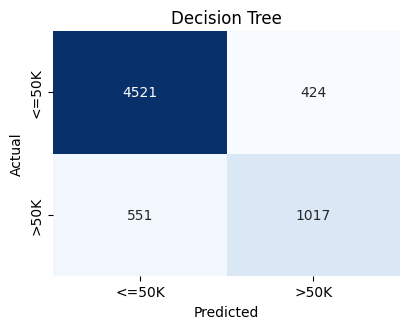

              precision    recall  f1-score   support

       <=50K       0.89      0.91      0.90      4945
        >50K       0.71      0.65      0.68      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.78      0.79      6513
weighted avg       0.85      0.85      0.85      6513



In [4]:
# Confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.2, 3.4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Decision Tree")
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"],
                            zero_division=0))


## Save the pipeline and metrics

In [5]:
# Persist the trained pipeline and its metrics
dp.SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
dp.METRICS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(pipeline, dp.SAVED_MODELS_DIR / "decision_tree.pkl", compress=3)
with open(dp.METRICS_DIR / "decision_tree_metrics.json", "w") as fh:
    json.dump(metrics, fh, indent=2)

print("Saved saved_models/decision_tree.pkl and metrics/decision_tree_metrics.json")


Saved saved_models/decision_tree.pkl and metrics/decision_tree_metrics.json
